# Fine-tune DeReC on DRAGON

Train a Russian DeBERTa classifier to distinguish **grounded** from **ungrounded** RAG answers.

- Dataset: DRAGON (1200 examples = 600 grounded + 600 ungrounded)
- Base model: `deepvk/deberta-v1-base` (Russian DeBERTa v1)
- Binary classification: grounded=1, ungrounded=0

## Setup

In [2]:
!git clone -b feature/evaluate-fact-checking https://github.com/BigMak1/rag_fact_checking.git
!git -C rag_fact_checking pull

fatal: destination path 'rag_fact_checking' already exists and is not an empty directory.
Already up to date.


In [ ]:
!uv pip install --system \
    accelerate==1.1.1 \
    datasets==3.1.0 \
    scikit-learn==1.5.2 \
    transformers==4.48.0 \
    sentence-transformers \
    tqdm \
    tiktoken \
    protobuf \
    einops \
    sentencepiece \
    bitsandbytes \
    huggingface_hub \

Using Python 3.12.12 environment at: /usr
  × No solution found when resolving dependencies:                                  
  ╰─▶ Because faiss==1.5.3 has no wheels with a matching Python ABI tag (e.g.,
      `cp312`) and only faiss==1.5.3 is available, we can conclude that all
      versions of faiss cannot be used.
      And because you require faiss, we can conclude that your requirements
      are unsatisfiable.

      hint: You require CPython 3.12 (`cp312`), but we only found wheels for
      `faiss` (v1.5.3) with the following Python ABI tags: `cp27m`, `cp35m`,
      `cp36m`, `cp37m`


In [4]:
%%time
# %%capture

# !pip install -q -r rag_fact_checking/DEREC/requirements.txt1

CPU times: user 5 µs, sys: 1 µs, total: 6 µs
Wall time: 11.4 µs


In [5]:
import sys
import os
import json

import numpy as np
import torch
from datasets import load_dataset
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import DataLoader
from transformers import AutoConfig, AutoModelForSequenceClassification
import matplotlib.pyplot as plt

sys.path.insert(0, "rag_fact_checking/DEREC")
from dataset_load import DatasetReader, UnifiedDataset, DATASET_CONFIGS
from main import EvidenceClassificationPipeline, generate_run_id

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

ModuleNotFoundError: No module named 'faiss'

In [6]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

In [16]:
CLASSIFIER_MODEL_NAME = "ruDeberta"
DATASET_NAME = "DRAGON"
BATCH_SIZE = 8
LEARNING_RATE = 5e-6
EPOCH_SIZE = 10
SEED = 44

HF_DATASET_REPO = "Makson4ic/dragon-derec-dataset"
HF_MODEL_REPO = "Makson4ic/derec-dragon-ruDeberta"
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

BASE_DIR = "rag_fact_checking/DEREC"
DATASET_PATH = os.path.join(BASE_DIR, "dataset", DATASET_NAME)

run_id = generate_run_id()
save_dir = os.path.join(
    BASE_DIR,
    f"saved_models/{DATASET_NAME.lower()}_classifier/run_{run_id}"
)
os.makedirs(save_dir, exist_ok=True)
print(f"Run ID: {run_id}")
print(f"Save dir: {save_dir}")

Run ID: 20260226_130944_b416a5af
Save dir: rag_fact_checking/DEREC/saved_models/dragon_classifier/run_20260226_130944_b416a5af


## Load Dataset

In [8]:
# Load from HuggingFace Hub and save as local JSON for DatasetReader
ds = load_dataset(HF_DATASET_REPO)
os.makedirs(DATASET_PATH, exist_ok=True)

for split_name in ["train", "val", "test"]:
    records = list(ds[split_name])
    with open(os.path.join(DATASET_PATH, f"{split_name}.json"), "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)
    print(f"{split_name}: {len(records)} examples")

# Load via DatasetReader
train_data = DatasetReader.read_dataset(DATASET_NAME, DATASET_PATH, "train")
val_data = DatasetReader.read_dataset(DATASET_NAME, DATASET_PATH, "val")
test_data = DatasetReader.read_dataset(DATASET_NAME, DATASET_PATH, "test")

# Check class balance
for name, split in [("train", train_data), ("val", val_data), ("test", test_data)]:
    labels = [item["label"] for item in split]
    n_grounded = sum(labels)
    n_ungrounded = len(labels) - n_grounded
    print(f"{name}: grounded={n_grounded}, ungrounded={n_ungrounded}")

train: 840 examples
val: 180 examples
test: 180 examples
train: grounded=420, ungrounded=420
val: grounded=90, ungrounded=90
test: grounded=90, ungrounded=90


In [9]:
example = train_data[0]
print(f"Claim:\n{example['claim'][:300]}\n")
print(f"Evidence:\n{example['evidence'][:300]}\n")
print(f"Label: {example['label']}")

Claim:
question: Каков диапазон гонорара Анжелики Варум?
answer: 4 до 6 млн рублей

Evidence:
Певица Лариса Долина лишилась выступления в новогоднюю ночь в одном из московских ресторанов. Организаторы мероприятия решили заменить артистку на Анжелику Варум. Об этом сообщает Kp.ru .
По информации источника, в новогоднюю ночь Лариса Долина должна была выступить в ресторане «Пушкин» в Москве. В 

Label: 1


## Initialize Pipeline

In [10]:
pipeline = EvidenceClassificationPipeline(
    dataset_name=DATASET_NAME,
    classifier_model=CLASSIFIER_MODEL_NAME,
)

Initializing pipeline for DRAGON dataset
Using device: cuda
DRAGON: skipping retriever (evidence pre-computed)
Loading classifier model: ruDeberta


tokenizer_config.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at deepvk/deberta-v1-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train

In [17]:
%%time

pipeline.train(
    train_dataset=train_data,
    eval_dataset=val_data,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCH_SIZE,
    learning_rate=LEARNING_RATE,
    save_dir=save_dir,
)

Epoch 1/10: 100%|██████████| 105/105 [01:36<00:00,  1.09it/s, loss=0.6982]



Epoch 1 Training Metrics:
accuracy: 0.4988
precision: 0.4988
recall: 0.4988
f1: 0.4968


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 1 Validation Metrics:
accuracy: 0.5000
precision: 0.2500
recall: 0.5000
f1: 0.3333

Epoch 1 completed in: 0:01:44


Epoch 2/10: 100%|██████████| 105/105 [01:36<00:00,  1.09it/s, loss=0.6857]


...


Epoch 8 Training Metrics:
accuracy: 0.9393
precision: 0.9420
recall: 0.9393
f1: 0.9392

Epoch 8 Validation Metrics:
accuracy: 0.9056
precision: 0.9080
recall: 0.9056
f1: 0.9054

Epoch 8 completed in: 0:01:44


Epoch 9/10: 100%|██████████| 105/105 [01:36<00:00,  1.09it/s, loss=0.1910]



Epoch 9 Training Metrics:
accuracy: 0.9393
precision: 0.9424
recall: 0.9393
f1: 0.9392

Epoch 9 Validation Metrics:
accuracy: 0.9111
precision: 0.9119
recall: 0.9111
f1: 0.9111

Epoch 9 completed in: 0:01:44


Epoch 10/10: 100%|██████████| 105/105 [01:36<00:00,  1.09it/s, loss=0.1776]



Epoch 10 Training Metrics:
accuracy: 0.9512
precision: 0.9523
recall: 0.9512
f1: 0.9512

Epoch 10 Validation Metrics:
accuracy: 0.9167
precision: 0.9180
recall: 0.9167
f1: 0.9166

Epoch 10 completed in: 0:01:44

Training Summary:
Best performance achieved in epoch 10:
accuracy: 0.9167
precision: 0.9180
recall: 0.9167
f1: 0.9166
CPU times: user 16min 44s, sys: 49.5 s, total: 17min 34s
Wall time: 17min 29s


## Evaluate on Test Set

In [18]:
# Load best checkpoint
best_model_path = os.path.join(save_dir, f"epoch_{pipeline.best_epoch}")
config = AutoConfig.from_pretrained(best_model_path, local_files_only=True)
pipeline.classifier = AutoModelForSequenceClassification.from_pretrained(
    best_model_path,
    config=config,
    local_files_only=True,
    trust_remote_code=True,
).to(pipeline.device)
print(f"Loaded best model from epoch {pipeline.best_epoch}")

# Prepare test data
test_claims, test_evidences, test_labels = pipeline.process_dragon_dataset(test_data)
test_dataset = UnifiedDataset(
    test_claims, test_evidences, test_labels, DATASET_NAME, pipeline.tokenizer
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Single inference pass: collect logits and labels
pipeline.classifier.eval()
all_logits = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(pipeline.device) for k, v in batch.items()}
        outputs = pipeline.classifier(**inputs)
        all_logits.append(outputs.logits.cpu())
        all_labels.append(inputs["labels"].cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()
all_preds = torch.argmax(all_logits, dim=1).numpy()

# Basic metrics
test_metrics = pipeline._calculate_metrics(all_labels, all_preds)
print("\nTest set metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Loaded best model from epoch 10

Test set metrics:
  accuracy: 0.9333
  precision: 0.9342
  recall: 0.9333
  f1: 0.9333


In [19]:
# ROC-AUC from softmax probabilities
probs = torch.softmax(all_logits, dim=-1)[:, 1].numpy()

auc = roc_auc_score(all_labels, probs)
fpr, tpr, thresholds = roc_curve(all_labels, probs)

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"ROC-AUC: {auc:.4f}")
print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"  TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}")

ROC-AUC: 0.9674
Optimal threshold (Youden's J): 0.9270
  TPR: 0.9000, FPR: 0.0111


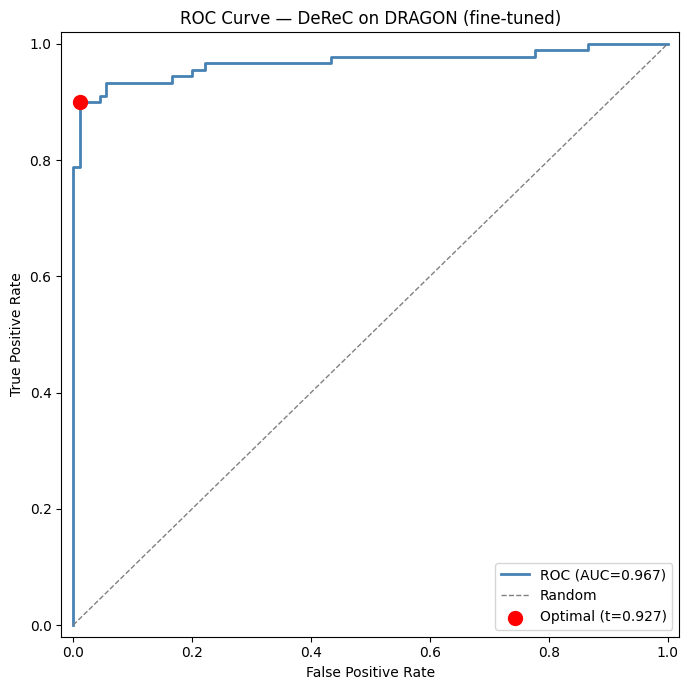

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
ax.scatter([fpr[best_idx]], [tpr[best_idx]], color="red", s=100, zorder=5,
           label=f"Optimal (t={best_threshold:.3f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — DeReC on DRAGON (fine-tuned)")
ax.legend(loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

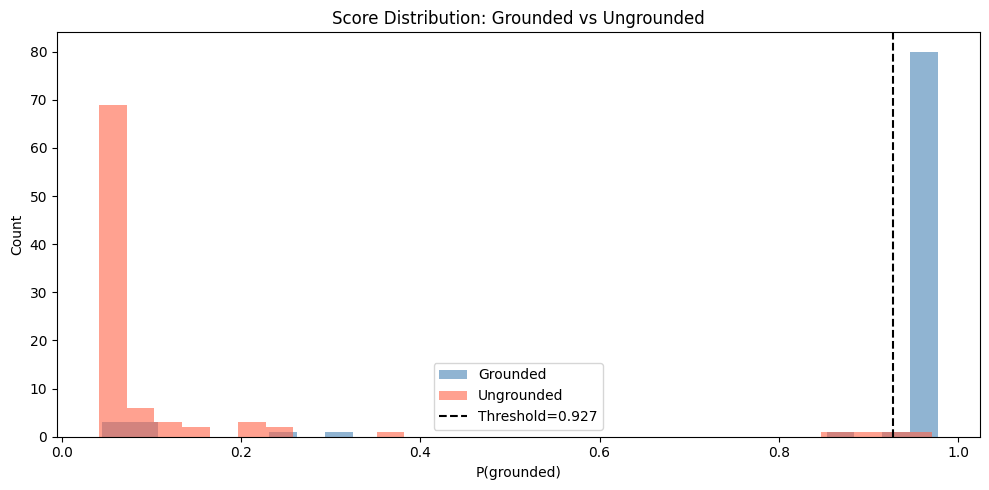

In [21]:
grounded_probs = probs[all_labels == 1]
ungrounded_probs = probs[all_labels == 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(grounded_probs, bins=30, alpha=0.6, label="Grounded", color="steelblue")
ax.hist(ungrounded_probs, bins=30, alpha=0.6, label="Ungrounded", color="tomato")
ax.axvline(best_threshold, color="black", linestyle="--",
           label=f"Threshold={best_threshold:.3f}")
ax.set_xlabel("P(grounded)")
ax.set_ylabel("Count")
ax.set_title("Score Distribution: Grounded vs Ungrounded")
ax.legend()
plt.tight_layout()
plt.show()

## Save Results

In [22]:
final_results = {
    "run_id": run_id,
    "best_epoch": pipeline.best_epoch,
    "test_metrics": test_metrics,
    "roc_auc": auc,
    "optimal_threshold": float(best_threshold),
    "config": {
        "classifier_model": CLASSIFIER_MODEL_NAME,
        "dataset": DATASET_NAME,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCH_SIZE,
        "seed": SEED,
    },
}

results_path = os.path.join(save_dir, "final_results.json")
with open(results_path, "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Results saved to {results_path}")
print(json.dumps(final_results, indent=2))

Results saved to rag_fact_checking/DEREC/saved_models/dragon_classifier/run_20260226_130944_b416a5af/final_results.json
{
  "run_id": "20260226_130944_b416a5af",
  "best_epoch": 10,
  "test_metrics": {
    "accuracy": 0.9333333333333333,
    "precision": 0.9341909945571499,
    "recall": 0.9333333333333333,
    "f1": 0.933300395256917
  },
  "roc_auc": 0.9674074074074074,
  "optimal_threshold": 0.9269759654998779,
  "config": {
    "classifier_model": "ruDeberta",
    "dataset": "DRAGON",
    "batch_size": 8,
    "learning_rate": 5e-06,
    "epochs": 10,
    "seed": 44
  }
}


## Publish to HuggingFace

In [23]:
from huggingface_hub import HfApi

assert HF_TOKEN, "Set HF_TOKEN in the constants cell"

api = HfApi(token=HF_TOKEN)
checkpoint_dir = os.path.join(save_dir, f"epoch_{pipeline.best_epoch}")

api.create_repo(repo_id=HF_MODEL_REPO, exist_ok=True)
api.upload_folder(
    folder_path=checkpoint_dir,
    repo_id=HF_MODEL_REPO,
    repo_type="model",
)
print(f"Uploaded to https://huggingface.co/{HF_MODEL_REPO}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to https://huggingface.co/Makson4ic/derec-dragon-ruDeberta
